In [2]:
from coffea.util import load
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [46]:
ggf_signal = load("/work/tharte/datasets/samples_vbf_boosted/vbf_ggf/1_16_3_fixed_workflow/output_GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE.coffea")
vbf_signal = load("/work/tharte/datasets/samples_vbf_boosted/vbf_ggf/1_16_3_fixed_workflow/output_VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE.coffea")
# data_e = load("/work/tharte/datasets/samples_vbf_boosted/vbf_ggf/1_16_3_fixed_workflow/output_DATA_JetMET_JMENano_E_2022_postEE_EraE.coffea")
# data_f = load("/work/tharte/datasets/samples_vbf_boosted/vbf_ggf/1_16_3_fixed_workflow/output_DATA_JetMET_JMENano_F_2022_postEE_EraF.coffea")
# vbf_signal_after_restructure = load("/work/tharte/datasets/samples_vbf_boosted/1_16_2_ggf_vs_vbf/1_16_2_vbf_with_discriminator_new_ordering/output_VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE.coffea")
vbf_signal_ar_debug = load("/work/tharte/datasets/samples_vbf_boosted/vbf_ggf/1_16_3_fixed_workflow/output_VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE.coffea")
# ggf_signal_after_restructure = load("/work/tharte/datasets/samples_vbf_boosted/1_16_2_ggf_vs_vbf/1_16_2_vbf_with_discriminator_new_ordering/output_GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE.coffea")

In [47]:
ggf_signal_ggf = ggf_signal["columns"]['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_skimmed']['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE']['boosted_vbf_fail_region']["nominal"]
ggf_signal_vbf = ggf_signal["columns"]['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_skimmed']['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE']['boosted_vbf_pass_region']["nominal"]

In [48]:
ggf_signal_ggf_ar = ggf_signal_after_restructure["columns"]['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_skimmed']['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE']['boosted_vbf_fail_region']["nominal"]
ggf_signal_vbf_ar = ggf_signal_after_restructure["columns"]['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_skimmed']['GluGlutoHHto4B_spanet_kl-1p00_kt-1p00_c2-0p00_2022_postEE']['boosted_vbf_pass_region']["nominal"]

NameError: name 'ggf_signal_after_restructure' is not defined

In [49]:
vbf_signal_ggf = vbf_signal["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']['boosted_vbf_fail_region']["nominal"]
vbf_signal_vbf = vbf_signal["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']['boosted_vbf_pass_region']["nominal"]
vbf_signal_all = vbf_signal["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']
print(vbf_signal_all.keys())
print(len(vbf_signal_all["boosted_vbf_signal_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_vbf_ttbar_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_vbf_qcd_A_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_vbf_qcd_B_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_vbf_qcd_C_region"]["nominal"]["weight"].value))

dict_keys(['boosted_vbf_signal_region', 'boosted_vbf_ttbar_region', 'boosted_vbf_pass_region', 'boosted_vbf_fail_region', 'boosted_vbf_qcd_A_region', 'boosted_vbf_qcd_B_region', 'boosted_vbf_qcd_C_region'])
1025


In [50]:
vbf_signal_ggf_ar = vbf_signal_after_restructure["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']['boosted_vbf_fail_region']["nominal"]
vbf_signal_vbf_ar = vbf_signal_after_restructure["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']['boosted_vbf_pass_region']["nominal"]
vbf_signal_all_ar = vbf_signal_after_restructure["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']
print(vbf_signal_all_ar.keys())
print(len(vbf_signal_all_ar["boosted_vbf_signal_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_ttbar_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_qcd_A_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_qcd_B_region"]["nominal"]["weight"].value)+len(vbf_signal_all["boosted_qcd_C_region"]["nominal"]["weight"].value))

NameError: name 'vbf_signal_after_restructure' is not defined

In [51]:
vbf_signal_ggf_ar_debug = vbf_signal_ar_debug["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']['boosted_vbf_fail_region']["nominal"]
vbf_signal_vbf_ar_debug = vbf_signal_ar_debug["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']['boosted_vbf_pass_region']["nominal"]
vbf_signal_all_ar_debug = vbf_signal_ar_debug["columns"]['VBFHHto4B_CV_1_C2V_1_C3_1']['VBFHHto4B_CV_1_C2V_1_C3_1__2022_postEE']

In [52]:
data_ggf = data_e["columns"]['DATA_JetMET_JMENano_E_skimmed']['DATA_JetMET_JMENano_E_2022_postEE_EraE']['boosted_vbf_fail_region']["nominal"]
data_vbf = data_e["columns"]['DATA_JetMET_JMENano_E_skimmed']['DATA_JetMET_JMENano_E_2022_postEE_EraE']['boosted_vbf_pass_region']["nominal"]

KeyError: 'DATA_JetMET_JMENano_E_skimmed'

In [53]:
data_f_ggf = data_f["columns"]['DATA_JetMET_JMENano_F_skimmed']['DATA_JetMET_JMENano_F_2022_postEE_EraF']['boosted_vbf_fail_region']["nominal"]
data_f_vbf = data_f["columns"]['DATA_JetMET_JMENano_F_skimmed']['DATA_JetMET_JMENano_F_2022_postEE_EraF']['boosted_vbf_pass_region']["nominal"]

KeyError: 'DATA_JetMET_JMENano_F_skimmed'

In [54]:
print("Looking at ggF signal")
print(f"ggF classified sum: {sum(ggf_signal_ggf['weight'].value)}")
print(f"VBF classified sum: {sum(ggf_signal_vbf['weight'].value)}")
print(f"ggF classified len: {len(ggf_signal_ggf['weight'].value)}")
print(f"VBF classified len: {len(ggf_signal_vbf['weight'].value)}")

Looking at ggF signal
ggF classified sum: 69303.58541001755
VBF classified sum: 494.8177152226777
ggF classified len: 8440
VBF classified len: 58


In [55]:
print("Looking at ggF signal")
print(f"ggF classified sum: {sum(ggf_signal_ggf_ar['weight'].value)}")
print(f"VBF classified sum: {sum(ggf_signal_vbf_ar['weight'].value)}")
print(f"ggF classified len: {len(ggf_signal_ggf_ar['weight'].value)}")
print(f"VBF classified len: {len(ggf_signal_vbf_ar['weight'].value)}")

Looking at ggF signal


NameError: name 'ggf_signal_ggf_ar' is not defined

In [56]:
print("Looking at VBF signal")
print(f"ggF classified sum: {sum(vbf_signal_ggf['weight'].value)}")
print(f"VBF classified sum: {sum(vbf_signal_vbf['weight'].value)}")
print(f"ggF classified len: {len(vbf_signal_ggf['weight'].value)}")
print(f"VBF classified len: {len(vbf_signal_vbf['weight'].value)}")
print(Counter(vbf_signal_ggf["JetGoodVBF_N"].value))
# print(Counter(vbf_signal_ggf["DiJetVBFCandidates_pt"].value))

Looking at VBF signal
ggF classified sum: 80524.79618700808
VBF classified sum: 18566.863834199776
ggF classified len: 4710
VBF classified len: 1086
Counter({2: 4710})


In [57]:
print("Looking at VBF signal")
print(f"ggF classified sum: {sum(vbf_signal_ggf_ar['weight'].value)}")
print(f"VBF classified sum: {sum(vbf_signal_vbf_ar['weight'].value)}")
print(f"ggF classified len: {len(vbf_signal_ggf_ar['weight'].value)}")
print(f"VBF classified len: {len(vbf_signal_vbf_ar['weight'].value)}")

Looking at VBF signal


NameError: name 'vbf_signal_ggf_ar' is not defined

In [58]:
print("Looking at VBF signal")
print(f"ggF classified sum: {sum(vbf_signal_ggf_ar_debug['weight'].value)}")
print(f"VBF classified sum: {sum(vbf_signal_vbf_ar_debug['weight'].value)}")
print(f"ggF classified len: {len(vbf_signal_ggf_ar_debug['weight'].value)}")
print(f"VBF classified len: {len(vbf_signal_vbf_ar_debug['weight'].value)}")
print(Counter(vbf_signal_ggf_ar_debug["LeadingVBFJet_phi"].value[vbf_signal_ggf_ar_debug["LeadingVBFJet_phi"].value>6]))
print(Counter(vbf_signal_ggf_ar_debug["JetGoodVBF_N"].value))
# print(Counter(vbf_signal_ggf_ar_debug["DiJetVBF_N"].value))

Looking at VBF signal
ggF classified sum: 80524.79618700808
VBF classified sum: 18566.863834199776
ggF classified len: 4710
VBF classified len: 1086
Counter()
Counter({2: 4710})


In [59]:
print("Looking at data")
print(f"ggF classified: {sum(data_ggf['weight'].value)}")
print(f"VBF classified: {sum(data_vbf['weight'].value)}")

Looking at data


NameError: name 'data_ggf' is not defined

In [60]:
print("Looking at data f")
print(f"ggF classified: {sum(data_f_ggf['weight'].value)}")
print(f"VBF classified: {sum(data_f_vbf['weight'].value)}")

Looking at data f


NameError: name 'data_f_ggf' is not defined

In [61]:
vbf_signal_vbf.keys()

dict_keys(['weight', 'JetGoodVBFCandidates_N', 'JetGoodVBFCandidates_phi', 'JetGoodVBFCandidates_eta', 'JetGoodVBFCandidates_provenance', 'JetGoodVBFCandidates_pt', 'JetGoodVBFCandidates_mass', 'events_dEta', 'events_year', 'events_era', 'events_HT', 'HiggsLeading_phi', 'HiggsLeading_eta', 'HiggsLeading_m_Hjet_min_dR', 'HiggsLeading_pt', 'HiggsLeading_dR_Hjet_min', 'HiggsLeading_btagBB_3wp', 'HiggsLeading_mass_regr', 'HiggsLeading_centrality', 'HiggsSubLeading_phi', 'HiggsSubLeading_eta', 'HiggsSubLeading_m_Hjet_min_dR', 'HiggsSubLeading_pt', 'HiggsSubLeading_dR_Hjet_min', 'HiggsSubLeading_btagBB_3wp', 'HiggsSubLeading_mass_regr', 'HiggsSubLeading_centrality', 'HH_phi', 'HH_eta', 'HH_dPhi', 'HH_dR', 'HH_pt', 'HH_mass', 'HH_dEta', 'HH_Costhetastar_CS', 'LeadingVBFJet_phi', 'LeadingVBFJet_pt', 'LeadingVBFJet_eta', 'LeadingVBFJet_mass', 'SubLeadingVBFJet_phi', 'SubLeadingVBFJet_pt', 'SubLeadingVBFJet_eta', 'SubLeadingVBFJet_mass', 'MET_sumEt', 'JetGoodVBF_N', 'JetGoodVBF_provenance', 'eve

In [62]:
print(vbf_signal_vbf_ar_debug["HiggsLeading_eta"])
print(vbf_signal_vbf_ar_debug["HiggsSubLeading_eta"])

column_accumulator(array([-0.11846924, -0.98413086,  2.1269531 , ...,  0.56677246,
       -2.3081055 , -2.0605469 ], dtype=float32))
column_accumulator(array([ 1.4477539 ,  1.6743164 , -0.24234009, ...,  0.48809814,
        0.861084  , -0.9691162 ], dtype=float32))


In [63]:
print(max(abs(vbf_signal_vbf_ar_debug["HiggsLeading_eta"].value[abs(vbf_signal_vbf_ar_debug["HiggsLeading_eta"].value)<998])))
print(max(abs(vbf_signal_vbf_ar_debug["HiggsSubLeading_eta"].value)))

2.399414
2.3969727


In [64]:
print(max(abs(vbf_signal_vbf_ar["LeadingVBFJet_eta"].value)))
print(max(abs(vbf_signal_vbf_ar["SubLeadingVBFJet_eta"].value)))
print(min(abs(vbf_signal_vbf_ar["LeadingVBFJet_eta"].value)))
print(min(abs(vbf_signal_vbf_ar["SubLeadingVBFJet_eta"].value)))

NameError: name 'vbf_signal_vbf_ar' is not defined

In [65]:
print(max(abs(vbf_signal_vbf_ar["LeadingVBFJet_eta"].value)))
print(max(abs(vbf_signal_vbf_ar["SubLeadingVBFJet_eta"].value)))
print(min(abs(vbf_signal_vbf_ar["LeadingVBFJet_eta"].value)))
print(min(abs(vbf_signal_vbf_ar["SubLeadingVBFJet_eta"].value)))

NameError: name 'vbf_signal_vbf_ar' is not defined

# Boosted with new cuts Preparation for reweighting
I now changed the cuts to see, if we get a larger amount of events.
Changes performed:
- msd: 50 -> 40
- mass_regr_min: 50 -> 40
- mjj min: 400 -> 300
- subleading bbtag min: 0.05 -> 0.00

In [17]:
data_e = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_3_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06/output_DATA_JetMET_JMENano_E_2022_postEE_EraE.coffea")
data_f = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_3_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06/output_DATA_JetMET_JMENano_F_2022_postEE_EraF.coffea")
data_g = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_3_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06/output_DATA_JetMET_JMENano_G_2022_postEE_EraG.coffea")
ttbarto4Q = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_3_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06/output_TTto4Q__2022_postEE.coffea")
ttbarto2L2Nu = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_3_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06/output_TTto2L2Nu__2022_postEE.coffea")
ttbartolNu2Q = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_3_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06/output_TTtoLNu2Q__2022_postEE.coffea")

In [18]:
print(ttbarto4Q["sum_genweights"]["TTto4Q__2022_postEE"])
sum_genweights_4q = ttbarto4Q["sum_genweights"]["TTto4Q__2022_postEE"]
sum_genweights_2l2nu = ttbarto2L2Nu["sum_genweights"]["TTto2L2Nu__2022_postEE"]
sum_genweights_lnu2q = ttbartolNu2Q["sum_genweights"]["TTtoLNu2Q__2022_postEE"]

62196280000.0


In [19]:
datasets = [data_e, data_f, data_g]
eras = ["E", "F", "G"]

# Region A
region_dicts = [
    dataset["columns"][f'DATA_JetMET_JMENano_{era}'][f'DATA_JetMET_JMENano_{era}_2022_postEE_Era{era}']['boosted_vbf_incl_qcd_A_region']["nominal"]
    for dataset, era in zip(datasets, eras)
]
keys = region_dicts[0].keys()
data_region_A = {
    key: ak.concatenate([d[key].value for d in region_dicts])
    for key in keys
}
# Region B
region_dicts = [
    dataset["columns"][f'DATA_JetMET_JMENano_{era}'][f'DATA_JetMET_JMENano_{era}_2022_postEE_Era{era}']['boosted_vbf_incl_qcd_B_region']["nominal"]
    for dataset, era in zip(datasets, eras)
]
keys = region_dicts[0].keys()
data_region_B = {
    key: ak.concatenate([d[key].value for d in region_dicts])
    for key in keys
}
print(data_region_B.keys())
# Region C
region_dicts = [
    dataset["columns"][f'DATA_JetMET_JMENano_{era}'][f'DATA_JetMET_JMENano_{era}_2022_postEE_Era{era}']['boosted_vbf_incl_qcd_C_region']["nominal"]
    for dataset, era in zip(datasets, eras)
]
keys = region_dicts[0].keys()
data_region_C = {
    key: ak.concatenate([d[key].value for d in region_dicts])
    for key in keys
}
# Region D
region_dicts = [
    dataset["columns"][f'DATA_JetMET_JMENano_{era}'][f'DATA_JetMET_JMENano_{era}_2022_postEE_Era{era}']['boosted_vbf_incl_signal_region']["nominal"]
    for dataset, era in zip(datasets, eras)
]
keys = region_dicts[0].keys()
data_region_D = {
    key: ak.concatenate([d[key].value for d in region_dicts])
    for key in keys
}

datasets = [ttbarto4Q["columns"]["TTto4Q"]["TTto4Q__2022_postEE"], ttbarto2L2Nu["columns"]["TTto2L2Nu"]["TTto2L2Nu__2022_postEE"], ttbartolNu2Q["columns"]["TTtoLNu2Q"]["TTtoLNu2Q__2022_postEE"]]
# Region A
region_dicts = [
    dataset['boosted_vbf_incl_qcd_A_region']["nominal"]
    for dataset in datasets
]
keys = region_dicts[0].keys()
ttbar_region_A = {}
for key in keys:
    if "weight" not in key:
        ttbar_region_A[key] = ak.concatenate([d[key].value for d in region_dicts])
    else:
        ttbar_region_A[key] = ak.concatenate([d[key].value/sum_genw for d, sum_genw in zip(region_dicts, [sum_genweights_4q, sum_genweights_2l2nu, sum_genweights_lnu2q])])
print(ttbar_region_A.keys())
# Region B
region_dicts = [
    dataset['boosted_vbf_incl_qcd_B_region']["nominal"]
    for dataset in datasets
]
keys = region_dicts[0].keys()
ttbar_region_B = {}
for key in keys:
    if "weight" not in key:
        ttbar_region_B[key] = ak.concatenate([d[key].value for d in region_dicts])
    else:
        ttbar_region_B[key] = ak.concatenate([d[key].value/sum_genw for d, sum_genw in zip(region_dicts, [sum_genweights_4q, sum_genweights_2l2nu, sum_genweights_lnu2q])])
# Region C
region_dicts = [
    dataset['boosted_vbf_incl_qcd_C_region']["nominal"]
    for dataset in datasets
]
keys = region_dicts[0].keys()
ttbar_region_C = {}
for key in keys:
    if "weight" not in key:
        ttbar_region_C[key] = ak.concatenate([d[key].value for d in region_dicts])
    else:
        ttbar_region_C[key] = ak.concatenate([d[key].value/sum_genw for d, sum_genw in zip(region_dicts, [sum_genweights_4q, sum_genweights_2l2nu, sum_genweights_lnu2q])])
# Region D
region_dicts = [
    dataset['boosted_vbf_incl_signal_region']["nominal"]
    for dataset in datasets
]
keys = region_dicts[0].keys()
ttbar_region_D = {}
for key in keys:
    if "weight" not in key:
        ttbar_region_D[key] = ak.concatenate([d[key].value for d in region_dicts])
    else:
        ttbar_region_D[key] = ak.concatenate([d[key].value/sum_genw for d, sum_genw in zip(region_dicts, [sum_genweights_4q, sum_genweights_2l2nu, sum_genweights_lnu2q])])




dict_keys(['weight', 'events_event', 'JetGoodVBF_N', 'JetGoodVBF_eta', 'JetGoodVBF_mass', 'JetGoodVBF_provenance', 'JetGoodVBF_phi', 'JetGoodVBF_pt', 'events_dEta', 'events_era', 'events_year', 'events_HT', 'HiggsLeading_eta', 'HiggsLeading_btagBB', 'HiggsLeading_phi', 'HiggsLeading_m_Hjet_min_dR', 'HiggsLeading_mass_regr', 'HiggsLeading_btagBB_3wp', 'HiggsLeading_dR_Hjet_min', 'HiggsLeading_pt', 'HiggsLeading_centrality', 'HiggsSubLeading_eta', 'HiggsSubLeading_btagBB', 'HiggsSubLeading_phi', 'HiggsSubLeading_m_Hjet_min_dR', 'HiggsSubLeading_mass_regr', 'HiggsSubLeading_btagBB_3wp', 'HiggsSubLeading_dR_Hjet_min', 'HiggsSubLeading_pt', 'HiggsSubLeading_centrality', 'HH_eta', 'HH_mass', 'HH_dR', 'HH_dPhi', 'HH_phi', 'HH_dEta', 'HH_pt', 'HH_Costhetastar_CS', 'LeadingVBFJet_eta', 'LeadingVBFJet_pt', 'LeadingVBFJet_phi', 'LeadingVBFJet_mass', 'SubLeadingVBFJet_eta', 'SubLeadingVBFJet_pt', 'SubLeadingVBFJet_phi', 'SubLeadingVBFJet_mass', 'MET_sumEt', 'JetGoodVBFCandidates_N', 'JetGoodVBFCan

# Checking BBtagging in AB vs CD

In [20]:
print(data_region_A.keys())
bbtag_subl_AB_data = np.concatenate([data_region_A["HiggsSubLeading_btagBB"], data_region_B["HiggsSubLeading_btagBB"]])
weight_AB_data = np.concatenate([data_region_A["weight"], data_region_B["weight"]])
bbtag_subl_CD_data = np.concatenate([data_region_C["HiggsSubLeading_btagBB"], data_region_D["HiggsSubLeading_btagBB"]])
weight_CD_data = np.concatenate([data_region_C["weight"], data_region_D["weight"]])
bbtag_subl_AB_ttbar = np.concatenate([ttbar_region_A["HiggsSubLeading_btagBB"], ttbar_region_B["HiggsSubLeading_btagBB"]])
weight_AB_ttbar = np.concatenate([ttbar_region_A["weight"], ttbar_region_B["weight"]])
bbtag_subl_CD_ttbar = np.concatenate([ttbar_region_C["HiggsSubLeading_btagBB"], ttbar_region_D["HiggsSubLeading_btagBB"]])
weight_CD_ttbar = np.concatenate([ttbar_region_C["weight"], ttbar_region_D["weight"]])

dict_keys(['weight', 'events_event', 'JetGoodVBF_N', 'JetGoodVBF_eta', 'JetGoodVBF_mass', 'JetGoodVBF_provenance', 'JetGoodVBF_phi', 'JetGoodVBF_pt', 'events_dEta', 'events_era', 'events_year', 'events_HT', 'HiggsLeading_eta', 'HiggsLeading_btagBB', 'HiggsLeading_phi', 'HiggsLeading_m_Hjet_min_dR', 'HiggsLeading_mass_regr', 'HiggsLeading_btagBB_3wp', 'HiggsLeading_dR_Hjet_min', 'HiggsLeading_pt', 'HiggsLeading_centrality', 'HiggsSubLeading_eta', 'HiggsSubLeading_btagBB', 'HiggsSubLeading_phi', 'HiggsSubLeading_m_Hjet_min_dR', 'HiggsSubLeading_mass_regr', 'HiggsSubLeading_btagBB_3wp', 'HiggsSubLeading_dR_Hjet_min', 'HiggsSubLeading_pt', 'HiggsSubLeading_centrality', 'HH_eta', 'HH_mass', 'HH_dR', 'HH_dPhi', 'HH_phi', 'HH_dEta', 'HH_pt', 'HH_Costhetastar_CS', 'LeadingVBFJet_eta', 'LeadingVBFJet_pt', 'LeadingVBFJet_phi', 'LeadingVBFJet_mass', 'SubLeadingVBFJet_eta', 'SubLeadingVBFJet_pt', 'SubLeadingVBFJet_phi', 'SubLeadingVBFJet_mass', 'MET_sumEt', 'JetGoodVBFCandidates_N', 'JetGoodVBFCan

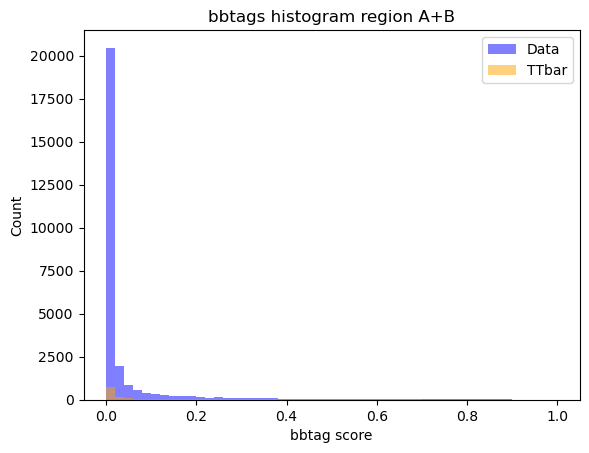

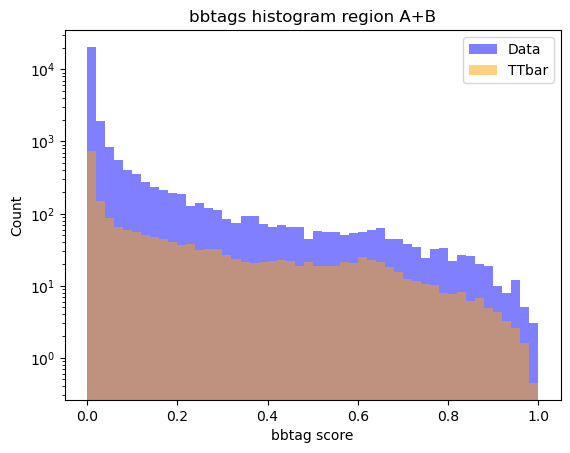

In [21]:
for scale in ["linear", "log"]:
    plt.hist(bbtag_subl_AB_data, bins=50, range=(0, 1), alpha=0.5, label="Data", weights=weight_AB_data, color="blue")
    plt.hist(bbtag_subl_AB_ttbar, bins=50, range=(0, 1), alpha=0.5, label="TTbar", weights=weight_AB_ttbar, color="orange")
    plt.xlabel('bbtag score')
    plt.ylabel('Count')
    plt.title('bbtags histogram region A+B')
    plt.yscale(scale)
    plt.legend()
    plt.show()

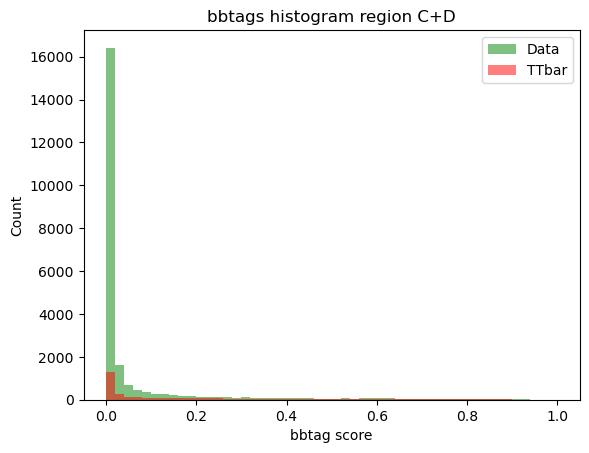

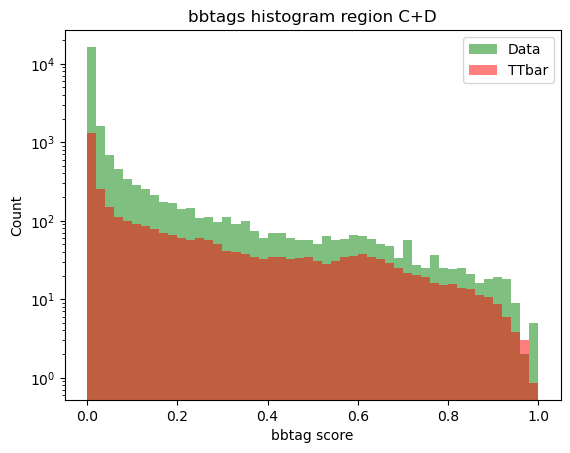

In [22]:
for scale in ["linear", "log"]:
    plt.hist(bbtag_subl_CD_data, bins=50, range=(0, 1), alpha=0.5, label="Data", weights=weight_CD_data, color="green")
    plt.hist(bbtag_subl_CD_ttbar, bins=50, range=(0, 1), alpha=0.5, label="TTbar", weights=weight_CD_ttbar, color="red")
    plt.xlabel('bbtag score')
    plt.ylabel('Count')
    plt.title('bbtags histogram region C+D')
    plt.yscale(scale)
    plt.legend()
    plt.show()

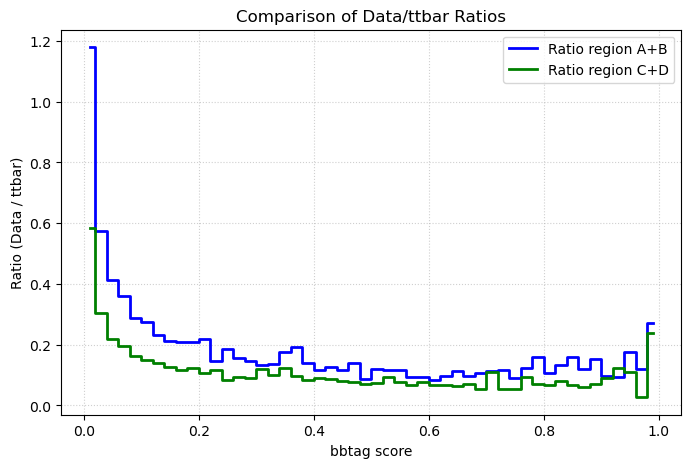

In [23]:
bins = 50
data_range = (0, 1) 

counts_data_AB, bin_edges = np.histogram(ak.to_numpy(bbtag_subl_AB_data), bins=bins, range=data_range)
counts_ttbar_AB, _ = np.histogram(bbtag_subl_AB_ttbar, bins=bin_edges)

counts_data_CD, _ = np.histogram(bbtag_subl_CD_data, bins=bin_edges)
counts_ttbar_CD, _ = np.histogram(bbtag_subl_CD_ttbar, bins=bin_edges)

ratio_AB = np.divide(
    counts_data_AB, 
    counts_ttbar_AB, 
    out=np.zeros_like(counts_data_AB, dtype=float), 
    where=counts_ttbar_AB != 0
)

ratio_CD = np.divide(
    counts_data_CD, 
    counts_ttbar_CD, 
    out=np.zeros_like(counts_data_CD, dtype=float), 
    where=counts_ttbar_CD != 0
)

# --- 4. Plotting ---
# For ratio plots, plotting at the bin centers using a step function is standard.
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(8, 5))

# Plot the AB ratio
plt.step(bin_centers, ratio_AB, where='mid', label='Ratio region A+B', color='blue', linewidth=2)

# Plot the CD ratio
plt.step(bin_centers, ratio_CD, where='mid', label='Ratio region C+D', color='green', linewidth=2)

# Add standard visual aids for ratio plots
plt.xlabel('bbtag score')
plt.ylabel('Ratio (Data / ttbar)')
plt.title('Comparison of Data/ttbar Ratios')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

# Checking mass distribution of leading higgs for region A+C vs region B+D

In [24]:
print(data_region_A.keys())
mass_AC_data = np.concatenate([data_region_A["HiggsLeading_mass_regr"], data_region_C["HiggsLeading_mass_regr"]])
weight_AC_data = np.concatenate([data_region_A["weight"], data_region_C["weight"]])
mass_BD_data = np.concatenate([data_region_B["HiggsLeading_mass_regr"], data_region_D["HiggsLeading_mass_regr"]])
weight_BD_data = np.concatenate([data_region_B["weight"], data_region_D["weight"]])
mass_AC_ttbar = np.concatenate([ttbar_region_A["HiggsLeading_mass_regr"], ttbar_region_C["HiggsLeading_mass_regr"]])
weight_AC_ttbar = np.concatenate([ttbar_region_A["weight"], ttbar_region_C["weight"]])
mass_BD_ttbar = np.concatenate([ttbar_region_B["HiggsLeading_mass_regr"], ttbar_region_D["HiggsLeading_mass_regr"]])
weight_BD_ttbar = np.concatenate([ttbar_region_B["weight"], ttbar_region_D["weight"]])
print(mass_AC_data)
print(weight_AC_data)
print(mass_AC_ttbar)
print(weight_AC_ttbar)

dict_keys(['weight', 'events_event', 'JetGoodVBF_N', 'JetGoodVBF_eta', 'JetGoodVBF_mass', 'JetGoodVBF_provenance', 'JetGoodVBF_phi', 'JetGoodVBF_pt', 'events_dEta', 'events_era', 'events_year', 'events_HT', 'HiggsLeading_eta', 'HiggsLeading_btagBB', 'HiggsLeading_phi', 'HiggsLeading_m_Hjet_min_dR', 'HiggsLeading_mass_regr', 'HiggsLeading_btagBB_3wp', 'HiggsLeading_dR_Hjet_min', 'HiggsLeading_pt', 'HiggsLeading_centrality', 'HiggsSubLeading_eta', 'HiggsSubLeading_btagBB', 'HiggsSubLeading_phi', 'HiggsSubLeading_m_Hjet_min_dR', 'HiggsSubLeading_mass_regr', 'HiggsSubLeading_btagBB_3wp', 'HiggsSubLeading_dR_Hjet_min', 'HiggsSubLeading_pt', 'HiggsSubLeading_centrality', 'HH_eta', 'HH_mass', 'HH_dR', 'HH_dPhi', 'HH_phi', 'HH_dEta', 'HH_pt', 'HH_Costhetastar_CS', 'LeadingVBFJet_eta', 'LeadingVBFJet_pt', 'LeadingVBFJet_phi', 'LeadingVBFJet_mass', 'SubLeadingVBFJet_eta', 'SubLeadingVBFJet_pt', 'SubLeadingVBFJet_phi', 'SubLeadingVBFJet_mass', 'MET_sumEt', 'JetGoodVBFCandidates_N', 'JetGoodVBFCan

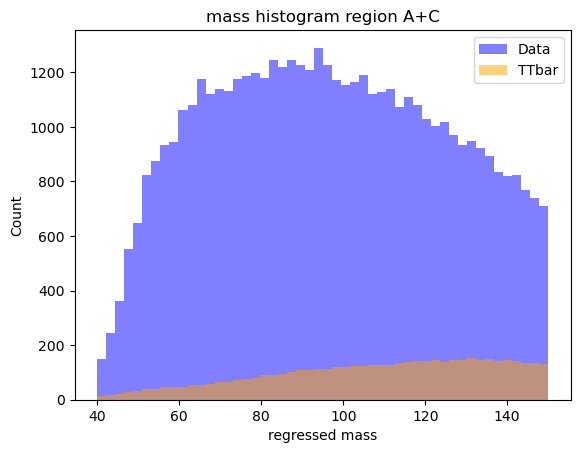

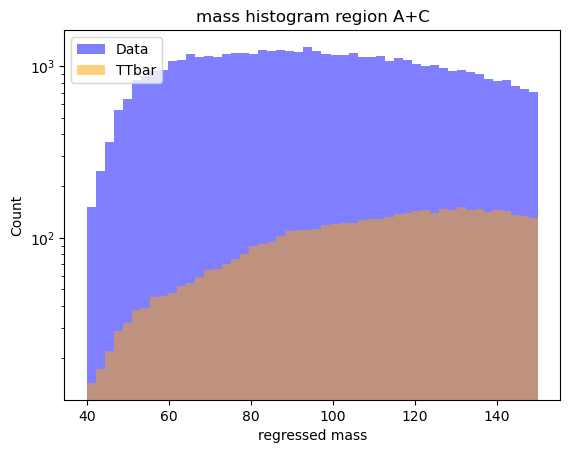

In [25]:
for scale in ["linear", "log"]:
    plt.hist(mass_AC_data, bins=50, range=(40, 150), alpha=0.5, label="Data", weights=weight_AC_data, color="blue")
    plt.hist(mass_AC_ttbar, bins=50, range=(40, 150), alpha=0.5, label="TTbar", weights=weight_AC_ttbar, color="orange")
    plt.xlabel('regressed mass')
    plt.ylabel('Count')
    plt.title('mass histogram region A+C')
    plt.yscale(scale)
    plt.legend()
    plt.show()

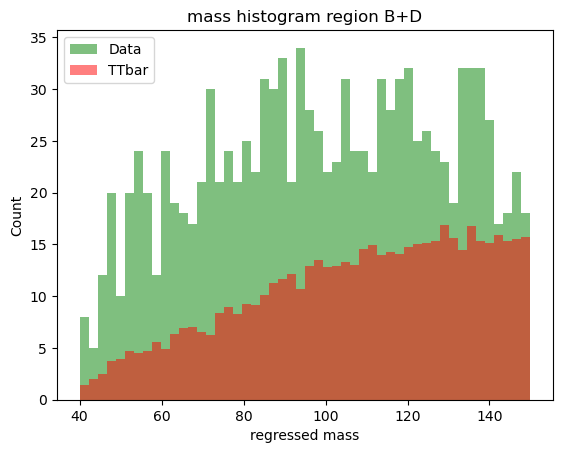

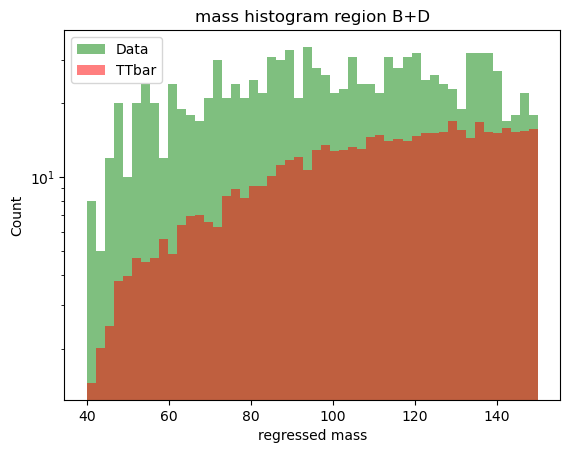

In [26]:
for scale in ["linear", "log"]:
    plt.hist(mass_BD_data, bins=50, range=(40, 150), alpha=0.5, label="Data", weights=weight_BD_data, color="green")
    plt.hist(mass_BD_ttbar, bins=50, range=(40, 150), alpha=0.5, label="TTbar", weights=weight_BD_ttbar, color="red")
    plt.xlabel('regressed mass')
    plt.ylabel('Count')
    plt.title('mass histogram region B+D')
    plt.yscale(scale)
    plt.legend()
    plt.show()

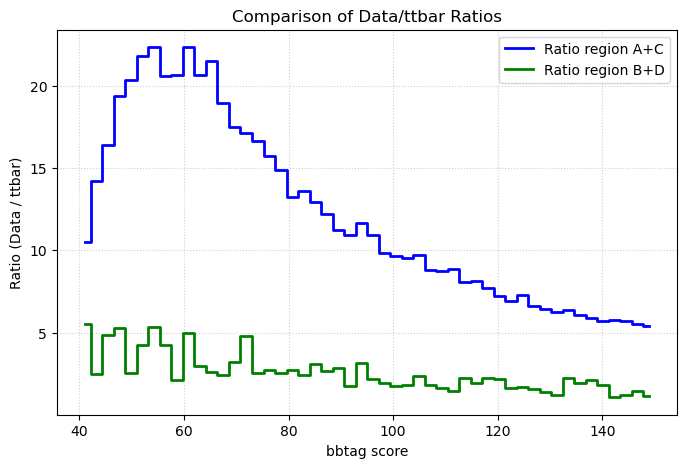

In [27]:
bins = 50
data_range = (40, 150) 

counts_data_AC, bin_edges = np.histogram(ak.to_numpy(mass_AC_data), bins=bins, range=data_range, weights=ak.to_numpy(weight_AC_data))
counts_ttbar_AC, _ = np.histogram(mass_AC_ttbar, bins=bin_edges, weights=weight_AC_ttbar)

counts_data_BD, _ = np.histogram(mass_BD_data, bins=bin_edges, weights=weight_BD_data)
counts_ttbar_BD, _ = np.histogram(mass_BD_ttbar, bins=bin_edges, weights=weight_BD_ttbar)

ratio_AC = np.divide(
    counts_data_AC, 
    counts_ttbar_AC, 
    out=np.zeros_like(counts_data_AB, dtype=float), 
    where=counts_ttbar_AB != 0
)

ratio_BD = np.divide(
    counts_data_BD, 
    counts_ttbar_BD, 
    out=np.zeros_like(counts_data_CD, dtype=float), 
    where=counts_ttbar_CD != 0
)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(8, 5))

# Plot the AB ratio
plt.step(bin_centers, ratio_AC, where='mid', label='Ratio region A+C', color='blue', linewidth=2)

# Plot the CD ratio
plt.step(bin_centers, ratio_BD, where='mid', label='Ratio region B+D', color='green', linewidth=2)

# Add standard visual aids for ratio plots
plt.xlabel('bbtag score')
plt.ylabel('Ratio (Data / ttbar)')
plt.title('Comparison of Data/ttbar Ratios')
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

dict_keys(['weight', 'events_event', 'JetGoodVBF_N', 'JetGoodVBF_eta', 'JetGoodVBF_mass', 'JetGoodVBF_provenance', 'JetGoodVBF_phi', 'JetGoodVBF_pt', 'events_dEta', 'events_era', 'events_year', 'events_HT', 'HiggsLeading_eta', 'HiggsLeading_btagBB', 'HiggsLeading_phi', 'HiggsLeading_m_Hjet_min_dR', 'HiggsLeading_mass_regr', 'HiggsLeading_btagBB_3wp', 'HiggsLeading_dR_Hjet_min', 'HiggsLeading_pt', 'HiggsLeading_centrality', 'HiggsSubLeading_eta', 'HiggsSubLeading_btagBB', 'HiggsSubLeading_phi', 'HiggsSubLeading_m_Hjet_min_dR', 'HiggsSubLeading_mass_regr', 'HiggsSubLeading_btagBB_3wp', 'HiggsSubLeading_dR_Hjet_min', 'HiggsSubLeading_pt', 'HiggsSubLeading_centrality', 'HH_eta', 'HH_mass', 'HH_dR', 'HH_dPhi', 'HH_phi', 'HH_dEta', 'HH_pt', 'HH_Costhetastar_CS', 'LeadingVBFJet_eta', 'LeadingVBFJet_pt', 'LeadingVBFJet_phi', 'LeadingVBFJet_mass', 'SubLeadingVBFJet_eta', 'SubLeadingVBFJet_pt', 'SubLeadingVBFJet_phi', 'SubLeadingVBFJet_mass', 'MET_sumEt', 'JetGoodVBFCandidates_N', 'JetGoodVBFCan

NameError: name 'eraE_regionA' is not defined

In [ ]:
print(len(bbtag_A))
print(len(bbtag_B))

## Side quest Checking subleading mask

In [30]:
print(data_region_A.keys())
mass_AC_data = np.concatenate([data_region_A["HiggsLeading_mass_regr"], data_region_C["HiggsSubLeading_mass_regr"]])
weight_AC_data = np.concatenate([data_region_A["weight"], data_region_C["weight"]])
mass_BD_data = np.concatenate([data_region_B["HiggsLeading_mass_regr"], data_region_D["HiggsSubLeading_mass_regr"]])
weight_BD_data = np.concatenate([data_region_B["weight"], data_region_D["weight"]])
mass_AC_ttbar = np.concatenate([ttbar_region_A["HiggsLeading_mass_regr"], ttbar_region_C["HiggsSubLeading_mass_regr"]])
weight_AC_ttbar = np.concatenate([ttbar_region_A["weight"], ttbar_region_C["weight"]])
mass_BD_ttbar = np.concatenate([ttbar_region_B["HiggsLeading_mass_regr"], ttbar_region_D["HiggsSubLeading_mass_regr"]])
weight_BD_ttbar = np.concatenate([ttbar_region_B["weight"], ttbar_region_D["weight"]])
print(mass_AC_data)
print(weight_AC_data)
print(mass_AC_ttbar)
print(weight_AC_ttbar)

dict_keys(['weight', 'events_event', 'JetGoodVBF_N', 'JetGoodVBF_eta', 'JetGoodVBF_mass', 'JetGoodVBF_provenance', 'JetGoodVBF_phi', 'JetGoodVBF_pt', 'events_dEta', 'events_era', 'events_year', 'events_HT', 'HiggsLeading_eta', 'HiggsLeading_btagBB', 'HiggsLeading_phi', 'HiggsLeading_m_Hjet_min_dR', 'HiggsLeading_mass_regr', 'HiggsLeading_btagBB_3wp', 'HiggsLeading_dR_Hjet_min', 'HiggsLeading_pt', 'HiggsLeading_centrality', 'HiggsSubLeading_eta', 'HiggsSubLeading_btagBB', 'HiggsSubLeading_phi', 'HiggsSubLeading_m_Hjet_min_dR', 'HiggsSubLeading_mass_regr', 'HiggsSubLeading_btagBB_3wp', 'HiggsSubLeading_dR_Hjet_min', 'HiggsSubLeading_pt', 'HiggsSubLeading_centrality', 'HH_eta', 'HH_mass', 'HH_dR', 'HH_dPhi', 'HH_phi', 'HH_dEta', 'HH_pt', 'HH_Costhetastar_CS', 'LeadingVBFJet_eta', 'LeadingVBFJet_pt', 'LeadingVBFJet_phi', 'LeadingVBFJet_mass', 'SubLeadingVBFJet_eta', 'SubLeadingVBFJet_pt', 'SubLeadingVBFJet_phi', 'SubLeadingVBFJet_mass', 'MET_sumEt', 'JetGoodVBFCandidates_N', 'JetGoodVBFCan

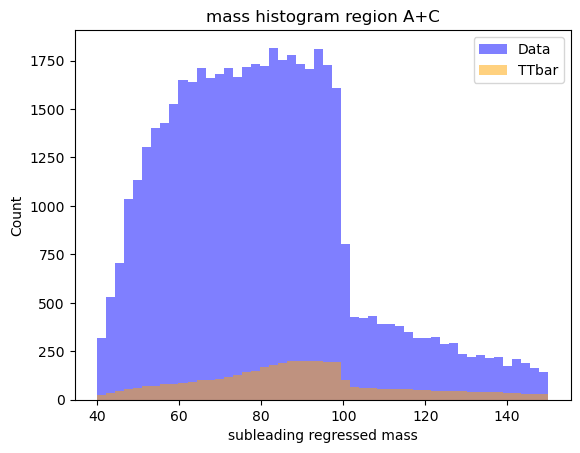

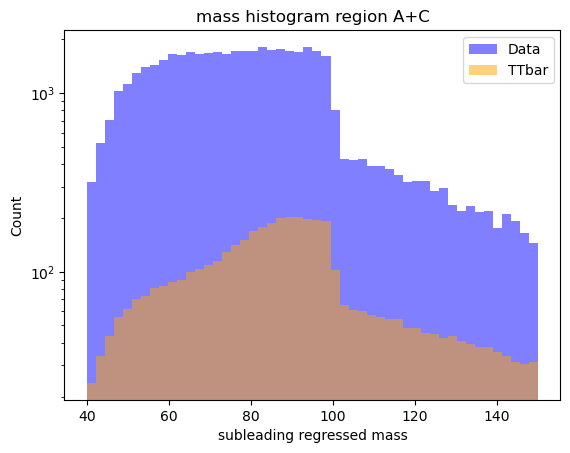

In [32]:
for scale in ["linear", "log"]:
    plt.hist(mass_AC_data, bins=50, range=(40, 150), alpha=0.5, label="Data", weights=weight_AC_data, color="blue")
    plt.hist(mass_AC_ttbar, bins=50, range=(40, 150), alpha=0.5, label="TTbar", weights=weight_AC_ttbar, color="orange")
    plt.xlabel('subleading regressed mass')
    plt.ylabel('Count')
    plt.title('mass histogram region A+C')
    plt.yscale(scale)
    plt.legend()
    plt.show()

# Testing without VBF requirements

In [48]:
data_e = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_4_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06_novbf_category/output_DATA_JetMET_JMENano_E_2022_postEE_EraE.coffea")
data_f = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_4_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06_novbf_category/output_DATA_JetMET_JMENano_F_2022_postEE_EraF.coffea")
data_g = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_4_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06_novbf_category/output_DATA_JetMET_JMENano_G_2022_postEE_EraG.coffea")
ttbarto4Q = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_4_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06_novbf_category/output_TTto4Q__2022_postEE.coffea")
ttbarto2L2Nu = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_4_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06_novbf_category/output_TTto2L2Nu__2022_postEE.coffea")
ttbartolNu2Q = load("/work/tharte/datasets/samples_vbf_boosted/no_model/1_16_4_unskimmed_datasets_data_ttbar_msd40_bsubl00_mjj300_bbtagBB_AB_cut06_novbf_category/output_TTtoLNu2Q__2022_postEE.coffea")

In [49]:
print(ttbarto4Q["sum_genweights"]["TTto4Q__2022_postEE"])
sum_genweights_4q = ttbarto4Q["sum_genweights"]["TTto4Q__2022_postEE"]
sum_genweights_2l2nu = ttbarto2L2Nu["sum_genweights"]["TTto2L2Nu__2022_postEE"]
sum_genweights_lnu2q = ttbartolNu2Q["sum_genweights"]["TTtoLNu2Q__2022_postEE"]

data_e["columns"]['DATA_JetMET_JMENano_E']['DATA_JetMET_JMENano_E_2022_postEE_EraE'].keys()

62196280000.0


dict_keys(['boosted_incl_region', 'boosted_incl_signal_region', 'boosted_incl_qcd_A_region', 'boosted_incl_qcd_B_region', 'boosted_incl_qcd_C_region'])

In [51]:
datasets = [data_e, data_f, data_g]
eras = ["E", "F", "G"]

# Region A
region_dicts = [
    dataset["columns"][f'DATA_JetMET_JMENano_{era}'][f'DATA_JetMET_JMENano_{era}_2022_postEE_Era{era}']['boosted_incl_qcd_A_region']["nominal"]
    for dataset, era in zip(datasets, eras)
]
keys = region_dicts[0].keys()
data_region_A = {
    key: ak.concatenate([d[key].value for d in region_dicts])
    for key in keys
}
# Region B
region_dicts = [
    dataset["columns"][f'DATA_JetMET_JMENano_{era}'][f'DATA_JetMET_JMENano_{era}_2022_postEE_Era{era}']['boosted_incl_qcd_B_region']["nominal"]
    for dataset, era in zip(datasets, eras)
]
keys = region_dicts[0].keys()
data_region_B = {
    key: ak.concatenate([d[key].value for d in region_dicts])
    for key in keys
}
print(data_region_B.keys())
# Region C
region_dicts = [
    dataset["columns"][f'DATA_JetMET_JMENano_{era}'][f'DATA_JetMET_JMENano_{era}_2022_postEE_Era{era}']['boosted_incl_qcd_C_region']["nominal"]
    for dataset, era in zip(datasets, eras)
]
keys = region_dicts[0].keys()
data_region_C = {
    key: ak.concatenate([d[key].value for d in region_dicts])
    for key in keys
}
# Region D
region_dicts = [
    dataset["columns"][f'DATA_JetMET_JMENano_{era}'][f'DATA_JetMET_JMENano_{era}_2022_postEE_Era{era}']['boosted_incl_signal_region']["nominal"]
    for dataset, era in zip(datasets, eras)
]
keys = region_dicts[0].keys()
data_region_D = {
    key: ak.concatenate([d[key].value for d in region_dicts])
    for key in keys
}

datasets = [ttbarto4Q["columns"]["TTto4Q"]["TTto4Q__2022_postEE"], ttbarto2L2Nu["columns"]["TTto2L2Nu"]["TTto2L2Nu__2022_postEE"], ttbartolNu2Q["columns"]["TTtoLNu2Q"]["TTtoLNu2Q__2022_postEE"]]
# Region A
region_dicts = [
    dataset['boosted_incl_qcd_A_region']["nominal"]
    for dataset in datasets
]
keys = region_dicts[0].keys()
ttbar_region_A = {}
for key in keys:
    if "weight" not in key:
        ttbar_region_A[key] = ak.concatenate([d[key].value for d in region_dicts])
    else:
        ttbar_region_A[key] = ak.concatenate([d[key].value/sum_genw for d, sum_genw in zip(region_dicts, [sum_genweights_4q, sum_genweights_2l2nu, sum_genweights_lnu2q])])
print(ttbar_region_A.keys())
# Region B
region_dicts = [
    dataset['boosted_incl_qcd_B_region']["nominal"]
    for dataset in datasets
]
keys = region_dicts[0].keys()
ttbar_region_B = {}
for key in keys:
    if "weight" not in key:
        ttbar_region_B[key] = ak.concatenate([d[key].value for d in region_dicts])
    else:
        ttbar_region_B[key] = ak.concatenate([d[key].value/sum_genw for d, sum_genw in zip(region_dicts, [sum_genweights_4q, sum_genweights_2l2nu, sum_genweights_lnu2q])])
# Region C
region_dicts = [
    dataset['boosted_incl_qcd_C_region']["nominal"]
    for dataset in datasets
]
keys = region_dicts[0].keys()
ttbar_region_C = {}
for key in keys:
    if "weight" not in key:
        ttbar_region_C[key] = ak.concatenate([d[key].value for d in region_dicts])
    else:
        ttbar_region_C[key] = ak.concatenate([d[key].value/sum_genw for d, sum_genw in zip(region_dicts, [sum_genweights_4q, sum_genweights_2l2nu, sum_genweights_lnu2q])])
# Region D
region_dicts = [
    dataset['boosted_incl_signal_region']["nominal"]
    for dataset in datasets
]
keys = region_dicts[0].keys()
ttbar_region_D = {}
for key in keys:
    if "weight" not in key:
        ttbar_region_D[key] = ak.concatenate([d[key].value for d in region_dicts])
    else:
        ttbar_region_D[key] = ak.concatenate([d[key].value/sum_genw for d, sum_genw in zip(region_dicts, [sum_genweights_4q, sum_genweights_2l2nu, sum_genweights_lnu2q])])




dict_keys(['weight', 'events_event', 'JetGoodVBF_N', 'JetGoodVBF_pt', 'JetGoodVBF_mass', 'JetGoodVBF_phi', 'JetGoodVBF_provenance', 'JetGoodVBF_eta', 'events_era', 'events_dEta', 'events_HT', 'events_year', 'HiggsLeading_pt', 'HiggsLeading_dR_Hjet_min', 'HiggsLeading_phi', 'HiggsLeading_m_Hjet_min_dR', 'HiggsLeading_eta', 'HiggsLeading_btagBB_3wp', 'HiggsLeading_centrality', 'HiggsLeading_btagBB', 'HiggsLeading_mass_regr', 'HiggsSubLeading_pt', 'HiggsSubLeading_dR_Hjet_min', 'HiggsSubLeading_phi', 'HiggsSubLeading_m_Hjet_min_dR', 'HiggsSubLeading_eta', 'HiggsSubLeading_btagBB_3wp', 'HiggsSubLeading_centrality', 'HiggsSubLeading_btagBB', 'HiggsSubLeading_mass_regr', 'HH_pt', 'HH_dR', 'HH_dPhi', 'HH_phi', 'HH_mass', 'HH_dEta', 'HH_eta', 'HH_Costhetastar_CS', 'LeadingVBFJet_pt', 'LeadingVBFJet_mass', 'LeadingVBFJet_eta', 'LeadingVBFJet_phi', 'SubLeadingVBFJet_pt', 'SubLeadingVBFJet_mass', 'SubLeadingVBFJet_eta', 'SubLeadingVBFJet_phi', 'MET_sumEt', 'JetGoodVBFCandidates_N', 'JetGoodVBFCan

In [56]:
print(f"Region A data: {len(data_region_A['weight'])}")
print(f"Region B data: {len(data_region_B['weight'])}")
print(f"Region C data: {len(data_region_C['weight'])}")
print(f"Region D data: {len(data_region_D['weight'])}")

Region A data: 421230
Region B data: 8275
Region C data: 315179
Region D data: 7974
